In [ ]:
# Library
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

### Polymarket EDA for Crypto

**Table of Contents**

1. Environment Setup and Data Loading

2. Data Preprocessing and Understanding

3. Analytical Plots

### 1. Environment Setup and Data Loading

In [ ]:
# Run EDA starter as the base
%run eda_starter_template.py


[Memory] Initial memory usage: 153.13 MB

Loading Bitcoin data from C:\Users\19741\Desktop\Study material\The London School of Economics and Politics\ST498 Capstone Project Bitcoin\lse-bitcoin-analytics-capstone-template\data\Coin Metrics\coinmetrics_btc.csv...
[Memory] Before loading Bitcoin data: 153.13 MB
[Memory] After loading Bitcoin data: 153.27 MB (Δ 0.13 MB)
Error loading Bitcoin data: 系统找不到指定的文件。 (os error 2): ...ct Bitcoin/lse-bitcoin-analytics-capstone-template/data/Coin Metrics/coinmetrics_btc.csv (set POLARS_VERBOSE=1 to see full path)
Loading Polymarket data from C:\Users\19741\Desktop\Study material\The London School of Economics and Politics\ST498 Capstone Project Bitcoin\lse-bitcoin-analytics-capstone-template\data\Polymarket...
[Memory] Before loading Polymarket data: 153.27 MB
[Memory] After loading Polymarket data: 153.27 MB (Δ 0.00 MB)

[Memory] Final memory usage: 153.27 MB (Total Δ: 0.13 MB)

EDA Layout Complete. Check the 'plots' directory for visualizations.


In [ ]:
# Download data
%run "C:/Users/19741/Desktop/Study material/The London School of Economics and Politics/ST498 Capstone Project Bitcoin/lse-bitcoin-analytics-capstone-template/data/download_data.py"

--- Downloading Capstone Data ---


Retrieving folder contents


Retrieving folder 1mgd1yrowPdQ0JKtdnKBQYHpvcdyRlXcV Coin Metrics
Processing file 1IUADRKckAZVoFYIJjTt9f_la-CQmnXIN coinmetrics_btc.csv
Processing file 1KVBZIl45-DnY0EzbA6-qFZi7kvu1iH8H coinmetrics_spec.md
Retrieving folder 1f_RjuR2AVTpuJeX6jgeoKcspjUp9_lif Polymarket
Processing file 14v0AUTMO6GwQ4ItLNRI8EuxLXplvCoGt finance_politics_event_stats.parquet
Processing file 1oF4B2zvi21br9a6NFVTwjAB8mfNuLdYx finance_politics_markets.parquet
Processing file 1z4nfPZL04Rkhp82piCvqRFerKBQbrXCh finance_politics_odds_history.parquet
Processing file 1QrWoxsFnfxv7Qs1lR4j2wpTs20MqOLnk finance_politics_summary.parquet
Processing file 1K1DjGkN4fkDMRXqZekS_-vRn-WErRLsz finance_politics_tokens.parquet
Processing file 1GO00RPaS7Q2ncX0fcUHiBLyy4bZR4_Yt finance_politics_trades.parquet
Processing file 1SwimJ6dcwl8TWUR1qKWsC1pzXAb9RHTs polymarket_btc_analytics_schema.md


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1IUADRKckAZVoFYIJjTt9f_la-CQmnXIN
To: c:\Users\19741\Desktop\Study material\The London School of Economics and Politics\ST498 Capstone Project Bitcoin\lse-bitcoin-analytics-capstone-template\eda\tmp_capstone_data\Coin Metrics\coinmetrics_btc.csv
100%|██████████| 2.42M/2.42M [00:00<00:00, 17.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1KVBZIl45-DnY0EzbA6-qFZi7kvu1iH8H
To: c:\Users\19741\Desktop\Study material\The London School of Economics and Politics\ST498 Capstone Project Bitcoin\lse-bitcoin-analytics-capstone-template\eda\tmp_capstone_data\Coin Metrics\coinmetrics_spec.md
100%|██████████| 4.85k/4.85k [00:00<?, ?B/s]
Downloading...
From: https://drive.google.com/uc?id=14v0AUTMO6GwQ4ItLNRI8EuxLXplvCoGt
To: c:\Users\19741\Desktop\Study material\The London School of Economics and Politics\ST498 Capstone Project Bitcoi

Organizing files...
  Keeping: Coin Metrics\coinmetrics_btc.csv
  Keeping: Coin Metrics\coinmetrics_spec.md
  Keeping: Polymarket\finance_politics_event_stats.parquet
  Keeping: Polymarket\finance_politics_markets.parquet
  Keeping: Polymarket\finance_politics_odds_history.parquet
  Keeping: Polymarket\finance_politics_summary.parquet
  Keeping: Polymarket\finance_politics_tokens.parquet
  Keeping: Polymarket\finance_politics_trades.parquet
  Keeping: Polymarket\polymarket_btc_analytics_schema.md

Successfully organized 9 file(s).
--- Finished downloading ---

Data download and organization complete.



Download completed


In [ ]:
# Path variables
COINMETRICS_PATH = "C:/Users/19741/Desktop/Study material/The London School of Economics and Politics/ST498 Capstone Project Bitcoin/lse-bitcoin-analytics-capstone-template/eda/data/Coin Metrics/coinmetrics_btc.csv"
POLYMARKET_DIR = "C:/Users/19741/Desktop/Study material/The London School of Economics and Politics/ST498 Capstone Project Bitcoin/lse-bitcoin-analytics-capstone-template/eda/data/Polymarket"

Loading Bitcoin data from C:/Users/19741/Desktop/Study material/The London School of Economics and Politics/ST498 Capstone Project Bitcoin/lse-bitcoin-analytics-capstone-template/eda/data/Coin Metrics/coinmetrics_btc.csv...
[Memory] Before loading Bitcoin data: 153.29 MB
[Memory] After loading Bitcoin data: 156.02 MB (Δ 2.73 MB)
Successfully loaded 6221 rows.


In [ ]:
# Load CoinMetric data and Polymarket data
btc_df = load_bitcoin_data(COINMETRICS_PATH)
poly_data = {}
for name, f in [('markets', 'finance_politics_markets.parquet'),
                ('odds_history', 'finance_politics_odds_history.parquet'),
                ('summary', 'finance_politics_summary.parquet'),
                ('tokens', 'finance_politics_tokens.parquet'), 
                ('trades', 'finance_politics_trades.parquet'),
                ('event_stats', 'finance_politics_event_stats.parquet')]:
    try:
        poly_data[name] = pd.read_parquet(os.path.join(POLYMARKET_DIR, f))
        print(f"✓ {name}: {len(poly_data[name]):,}")
    except:
        print(f"⚠ {name}: skipped")


✓ markets: 78,321
✓ odds_history: 2,143,181
✓ summary: 78,321
✓ tokens: 156,636
✓ trades: 27,013,724
✓ event_stats: 44,033


### 2. Data Preprocessing and Understanding

In [ ]:
# Check the categories of Polymarket data
category = poly_data['markets'].groupby('category')
print(category.groups.keys())
category.size()

dict_keys(['', 'Business', 'Coronavirus', 'Coronavirus-', 'Crypto', 'Global Politics', 'Politics', 'Pop-Culture ', 'Tech', 'US-current-affairs', 'Ukraine & Russia'])


category
                      77516
Business                113
Coronavirus               3
Coronavirus-              1
Crypto                  340
Global Politics          56
Politics                  1
Pop-Culture               4
Tech                      2
US-current-affairs      265
Ukraine & Russia         20
dtype: int64

In [52]:
# 1. Define your keyword map
keyword_map = {
    'Crypto': 'bitcoin|eth|solana|crypto|token|airdrop',
    'Politics': 'trump|biden|harris|election|senate|republican|democrat',
    'Ukraine & Russia': 'ukraine|russia|putin|zelensky|kremlin',
    'Pop-Culture': 'oscars|grammy|taylor swift|box office|celebrity',
    'Tech': 'ai|openai|gpt|google|nvidia|meta|apple',
    'Global Politics': 'israel|gaza|iran|china|taiwan|uk|london'
}

# 2. Filter for only the rows where category is blank
blank_mask = (poly_data['markets']['category'] == '') | (poly_data['markets']['category'].isna())

# 3. Loop through the map and update blank categories based on question text
for cat, keywords in keyword_map.items():
    # Only update if the row is currently blank AND the question contains a keyword
    match_mask = blank_mask & poly_data['markets']['question'].str.contains(keywords, case=False, na=False)
    poly_data['markets'].loc[match_mask, 'category'] = cat

# 4. See how many are left blank now
print(poly_data['markets']['category'].value_counts())

category
Crypto                57852
Politics              10909
                       7421
Tech                    766
Global Politics         694
Ukraine & Russia        293
US-current-affairs      265
Business                113
Pop-Culture               4
Coronavirus               3
Coronavirus-              1
Name: count, dtype: int64


In [ ]:
# Separate Polymarket data into different data frames
markets_df = poly_data['markets'].copy()
event_stats_df = poly_data['event_stats'].copy()
odds_history_df = poly_data['odds_history'].copy()
summary_df = poly_data['summary'].copy()
tokens_df = poly_data['tokens'].copy()
trades_df = poly_data['trades'].copy()

In [ ]:
# Filter Crypto category
crypto_markets = markets_df[markets_df["category"] == "Crypto"].copy()
crypto_event_stats = pd.merge(crypto_markets['event_slug'], event_stats_df, on = 'event_slug', how = 'left')
crypto_odds_history = pd.merge(odds_history_df, crypto_markets[['market_id', 'question']], on = 'market_id', how = 'left').dropna()
crypto_summary = pd.merge(markets_df['market_id'], summary_df, on = 'market_id', how = 'left')
crypto_tokens = pd.merge(tokens_df, crypto_markets[['market_id', 'question']], on = 'market_id', how = 'left').dropna()
crypto_trades = pd.merge(trades_df, crypto_markets[['market_id', 'question']],  on = 'market_id', how = 'left').dropna()

# Fix timestamp unit mismatch for data frames including timestamp column (ms values interpreted as us -> 1970 dates)
if pd.api.types.is_datetime64_any_dtype(crypto_trades["timestamp"]):
    if crypto_trades["timestamp"].dt.year.eq(1970).all():
        crypto_trades["timestamp"] = pd.to_datetime(
            crypto_trades["timestamp"].astype("int64"),
            unit="ms",
            errors="coerce",
        )

if pd.api.types.is_datetime64_any_dtype(crypto_odds_history["timestamp"]):
    if crypto_odds_history["timestamp"].dt.year.eq(1970).all():
        crypto_odds_history["timestamp"] = pd.to_datetime(
            crypto_odds_history["timestamp"].astype("int64"),
            unit="ms",
            errors="coerce",
        )

In [ ]:
# Check if we have the correct timestamp (without 1970s)
print(crypto_trades["timestamp"].min(), crypto_trades["timestamp"].max())
print(crypto_odds_history["timestamp"].min(), crypto_odds_history["timestamp"].max())


2025-04-07 08:05:19 2026-01-05 06:31:01
2023-02-03 00:00:56 2026-01-05 01:02:10


In [ ]:
# Summary info
print(crypto_markets.info())
print("\nMissing values:")
print(crypto_markets.isna().sum())
print()

<class 'pandas.core.frame.DataFrame'>
Index: 57852 entries, 3 to 78316
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   market_id   57852 non-null  object        
 1   question    57852 non-null  object        
 2   slug        57852 non-null  object        
 3   event_slug  57852 non-null  object        
 4   category    57852 non-null  object        
 5   volume      57852 non-null  float64       
 6   active      57852 non-null  bool          
 7   closed      57852 non-null  bool          
 8   created_at  57852 non-null  datetime64[us]
 9   end_date    57712 non-null  datetime64[us]
dtypes: bool(2), datetime64[us](2), float64(1), object(5)
memory usage: 4.1+ MB
None

Missing values:
market_id       0
question        0
slug            0
event_slug      0
category        0
volume          0
active          0
closed          0
created_at      0
end_date      140
dtype: int64



In [59]:
print(crypto_event_stats.info())
print("\nMissing values:")
print(crypto_event_stats.isna().sum())
print()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57852 entries, 0 to 57851
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   event_slug          57852 non-null  object        
 1   market_count        57852 non-null  int64         
 2   total_volume        57852 non-null  float64       
 3   first_market_start  57852 non-null  datetime64[us]
 4   last_market_end     57806 non-null  datetime64[us]
dtypes: datetime64[us](2), float64(1), int64(1), object(1)
memory usage: 2.2+ MB
None

Missing values:
event_slug             0
market_count           0
total_volume           0
first_market_start     0
last_market_end       46
dtype: int64



In [60]:
print(crypto_odds_history.info())
print("\nMissing values:")
print(crypto_odds_history.isna().sum())
print()

<class 'pandas.core.frame.DataFrame'>
Index: 553076 entries, 25924 to 2143094
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   market_id  553076 non-null  object        
 1   token_id   553076 non-null  object        
 2   timestamp  553076 non-null  datetime64[us]
 3   price      553076 non-null  float64       
 4   question   553076 non-null  object        
dtypes: datetime64[us](1), float64(1), object(3)
memory usage: 25.3+ MB
None

Missing values:
market_id    0
token_id     0
timestamp    0
price        0
question     0
dtype: int64



In [61]:
print(crypto_summary.info())
print("\nMissing values:")
print(crypto_summary.isna().sum())
print()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78321 entries, 0 to 78320
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   market_id    78321 non-null  object        
 1   question     78321 non-null  object        
 2   slug         78321 non-null  object        
 3   volume       78321 non-null  float64       
 4   active       78321 non-null  bool          
 5   token_count  78321 non-null  int64         
 6   trade_count  78321 non-null  int64         
 7   first_trade  36169 non-null  datetime64[us]
 8   last_trade   36169 non-null  datetime64[us]
dtypes: bool(1), datetime64[us](2), float64(1), int64(2), object(3)
memory usage: 4.9+ MB
None

Missing values:
market_id          0
question           0
slug               0
volume             0
active             0
token_count        0
trade_count        0
first_trade    42152
last_trade     42152
dtype: int64



In [62]:
print(crypto_tokens.info())
print("\nMissing values:")
print(crypto_tokens.isna().sum())
print()

<class 'pandas.core.frame.DataFrame'>
Index: 115694 entries, 58 to 156635
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   market_id  115694 non-null  object
 1   token_id   115694 non-null  object
 2   outcome    115694 non-null  object
 3   question   115694 non-null  object
dtypes: object(4)
memory usage: 4.4+ MB
None

Missing values:
market_id    0
token_id     0
outcome      0
question     0
dtype: int64



In [63]:
print(crypto_trades.info())
print("\nMissing values:")
print(crypto_trades.isna().sum())
print()

<class 'pandas.core.frame.DataFrame'>
Index: 21103424 entries, 1841946 to 27013680
Data columns (total 10 columns):
 #   Column         Dtype         
---  ------         -----         
 0   trade_id       object        
 1   market_id      object        
 2   token_id       object        
 3   timestamp      datetime64[us]
 4   price          float64       
 5   size           float64       
 6   side           object        
 7   maker_address  object        
 8   taker_address  object        
 9   question       object        
dtypes: datetime64[us](1), float64(2), object(7)
memory usage: 1.7+ GB
None

Missing values:
trade_id         0
market_id        0
token_id         0
timestamp        0
price            0
size             0
side             0
maker_address    0
taker_address    0
question         0
dtype: int64



In [ ]:
# Top 10 crypto markets by volumn
top10 = crypto_markets.sort_values("volume", ascending=False).head(10)

print(top10[["question", "volume"]])


                                               question        volume
4965                Will Bitcoin hit $100k in November?  2.858743e+07
218                     Will Bitcoin hit $100k in 2024?  2.280724e+07
627                     Ethereum all time high in 2024?  1.951018e+07
54737  Over $1.4B committed to the MegaETH public sale?  1.688234e+07
14932            Will Satoshi move any Bitcoin in 2025?  1.629100e+07
43395              Will Bitcoin reach $200k in October?  1.561720e+07
53349  Over $1.8B committed to the MegaETH public sale?  1.482415e+07
56394          Will Bitcoin reach $200,000 in November?  1.358862e+07
53492    Over $1B committed to the MegaETH public sale?  1.343146e+07
2141                   Ethereum ETF approved by May 31?  1.322651e+07


In [106]:
# --- Convert BTC polars DF to pandas ---
btc_pd = btc_df.to_pandas()

btc_pd['time'] = pd.to_datetime(btc_pd['time'])
btc_pd = btc_pd.sort_values('time')

# If price column name differs, adjust here:
btc_pd = btc_pd.rename(columns={'PriceUSD': 'btc_price'})

btc_pd['btc_return'] = btc_pd['btc_price'].pct_change()
btc_pd['btc_volatility_7d'] = btc_pd['btc_return'].rolling(7).std()

btc_pd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6221 entries, 0 to 6220
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   time                         6221 non-null   datetime64[us]
 1   AdrActCnt                    6220 non-null   float64       
 2   AdrBalCnt                    6220 non-null   float64       
 3   AssetCompletionTime          6220 non-null   float64       
 4   AssetEODCompletionTime       6220 non-null   float64       
 5   BlkCnt                       6220 non-null   float64       
 6   CapMVRVCur                   5659 non-null   float64       
 7   CapMrktCurUSD                5659 non-null   float64       
 8   CapMrktEstUSD                2398 non-null   float64       
 9   FeeTotNtv                    6220 non-null   float64       
 10  FlowInExNtv                  6220 non-null   float64       
 11  FlowInExUSD                  5659 non-null 

C:\Users\19741\AppData\Local\Temp\ipykernel_7532\3340433049.py:10: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  btc_pd['btc_return'] = btc_pd['btc_price'].pct_change()


In the data frame `btc_pd`, we introduced 2 new variables `btc_return` and `btc_volatility_7d`. The formulas are given below:

At day $t$, the BTC return is given by
$$\text{return}_t = \frac{\text{price}_t-\text{price}_{t-1}}{\text{price}_{t-1}},$$
i.e. daily BTC percentage price change;

The 7-day BTC volatility is given by
$$\text{volatility}^{(7)}_t = \sqrt{\frac{1}{6}\sum_{k=0}^6 (\text{return}_{t-k} - \frac{1}{7}\sum_{j=0}^6 \text{return}_{t-k})^2},$$
i.e. the 7-day rolling standard deviation of BTC return. It reflects short-term risk intensity.

We will use these variables in the following plots.


### 3. Analytical Plots

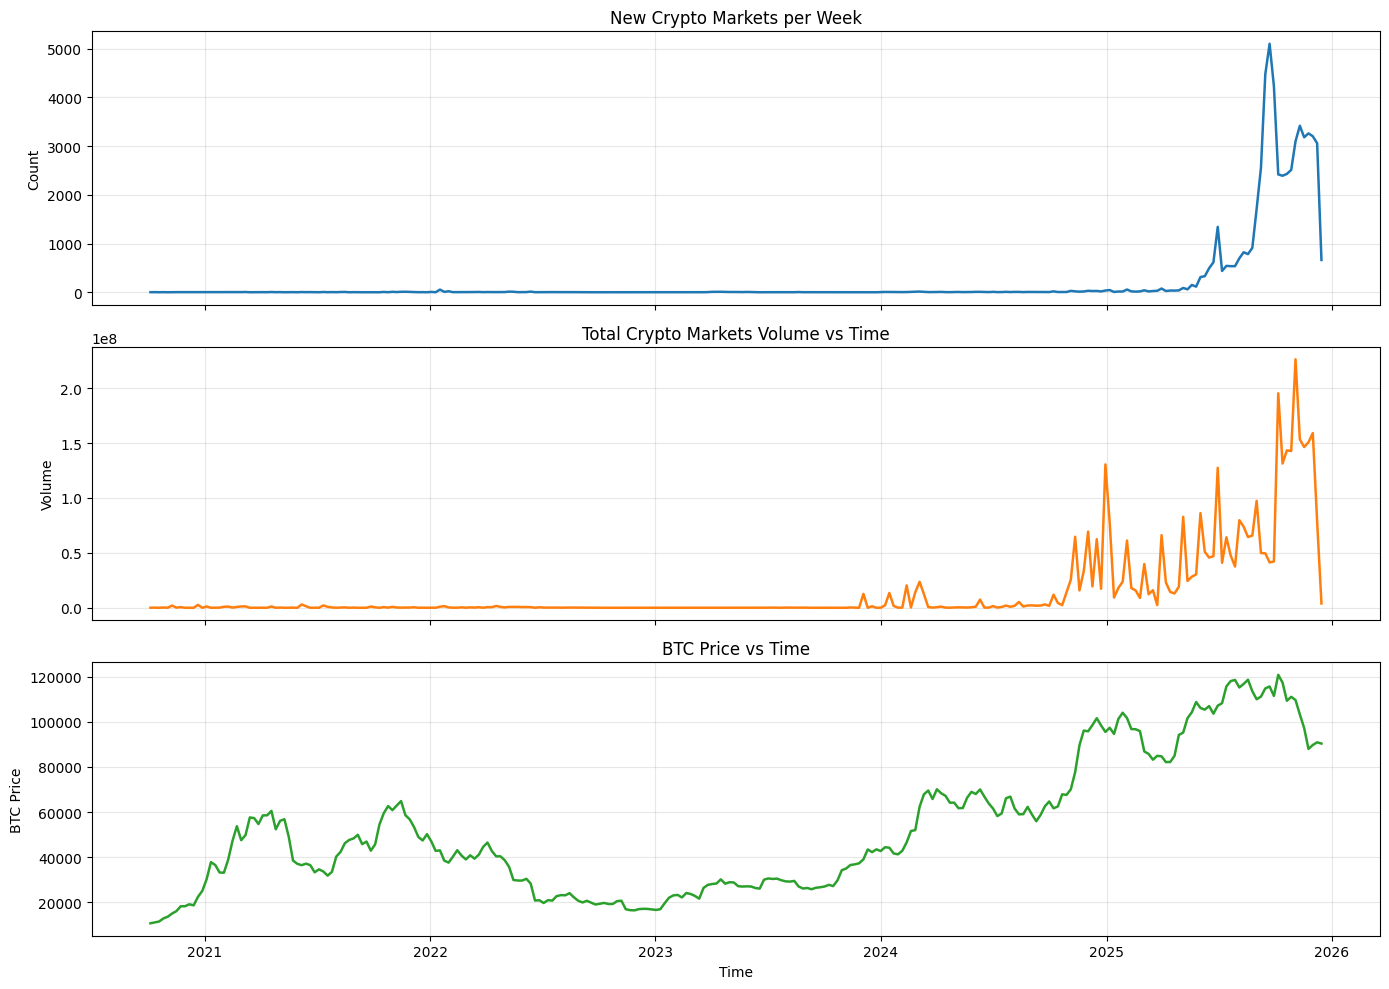

In [ ]:
# --- Ensure datetime / numeric types ---
crypto_markets['created_at'] = pd.to_datetime(crypto_markets['created_at'], errors='coerce')
crypto_markets['volume'] = pd.to_numeric(crypto_markets['volume'], errors='coerce')

btc_pd['time'] = pd.to_datetime(btc_pd['time'], errors='coerce')
btc_pd = btc_pd.sort_values('time')

# --- Weekly series ---
# 1) New crypto markets per week
markets_per_week = (
    crypto_markets
    .set_index('created_at')
    .resample('W-MON')  # weekly (Monday anchor), keeps x-axis consistent
    .size()
    .rename('market_count')
)

# 2) Total crypto markets volume per week
volume_per_week = (
    crypto_markets
    .set_index('created_at')
    .resample('W-MON')['volume']
    .sum()
    .rename('total_volume')
)

# 3) BTC price per week (use weekly mean; you can change to .last() if preferred)
btc_price_per_week = (
    btc_pd
    .set_index('time')
    .resample('W-MON')['btc_price']
    .mean()
    .rename('btc_price')
)

# Only draw the data points in the intersection of all 3 plots
aligned = pd.concat(
    [markets_per_week, volume_per_week, btc_price_per_week],
    axis=1,
    join='inner'
).dropna()

# --- Plot: 3 vertically aligned subplots with shared x-axis ---
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(
    aligned.index, aligned['market_count'],
    color='#1f77b4', linewidth=1.8
)
axes[0].set_title("New Crypto Markets per Week")
axes[0].set_ylabel("Count")
axes[0].grid(alpha=0.3)

axes[1].plot(
    aligned.index, aligned['total_volume'],
    color='#ff7f0e', linewidth=1.8
)
axes[1].set_title("Total Crypto Markets Volume vs Time")
axes[1].set_ylabel("Volume")
axes[1].grid(alpha=0.3)

axes[2].plot(
    aligned.index, aligned['btc_price'],
    color='#2ca02c', linewidth=1.8
)
axes[2].set_title("BTC Price vs Time")
axes[2].set_ylabel("BTC Price")
axes[2].set_xlabel("Time")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

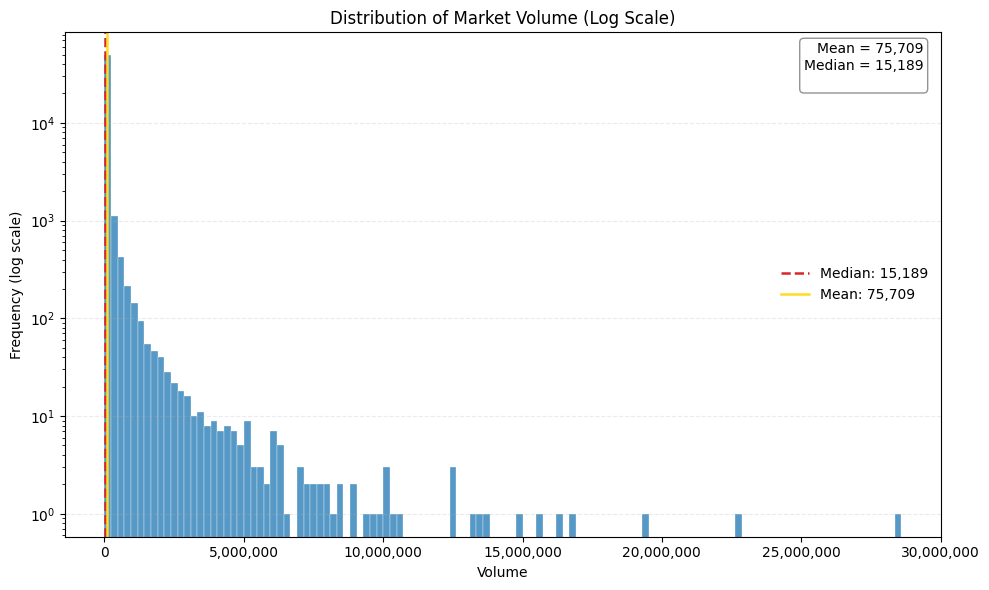

In [ ]:
# Draw distribution of volumn

vol = pd.to_numeric(crypto_markets['volume'], errors='coerce').dropna()
vol = vol[vol > 0]

# Statistics
mean_v = vol.mean()
median_v = vol.median()

plt.figure(figsize=(10, 6))
plt.hist(
    vol,
    bins=120,
    color='#1f77b4',
    alpha=0.75,
    edgecolor='white',
    linewidth=0.3
)

plt.yscale('log')
plt.title("Distribution of Market Volume (Log Scale)")
plt.xlabel("Volume")
plt.ylabel("Frequency (log scale)")
plt.grid(axis='y', alpha=0.25, linestyle='--')
plt.axvline(median_v, color='#d62728', linestyle='--', linewidth=1.8, label=f'Median: {median_v:,.0f}')
plt.axvline(mean_v,   color="#ffdb24", linestyle='-',  linewidth=1.8, label=f'Mean: {mean_v:,.0f}')
plt.gca().xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

# Text in the graph
txt = (
    f"Mean = {mean_v:,.0f}\n"
    f"Median = {median_v:,.0f}\n"
)
plt.text(
    0.98, 0.98, txt,
    transform=plt.gca().transAxes,
    ha='right', va='top',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='gray')
)

plt.legend(frameon=False)
plt.tight_layout()
plt.show()


**Interpretation:**

1. Highly right-skewed distribution.

2. Most markets have low volume.

3. A small number of markets dominate total trading.

This is typical of crypto speculation — a few headline markets attract most liquidity.

**Implication:**

Liquidity concentration → any market-level average may be heavily influenced by a few large markets.

C:\Users\19741\AppData\Local\Temp\ipykernel_7532\4192915795.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


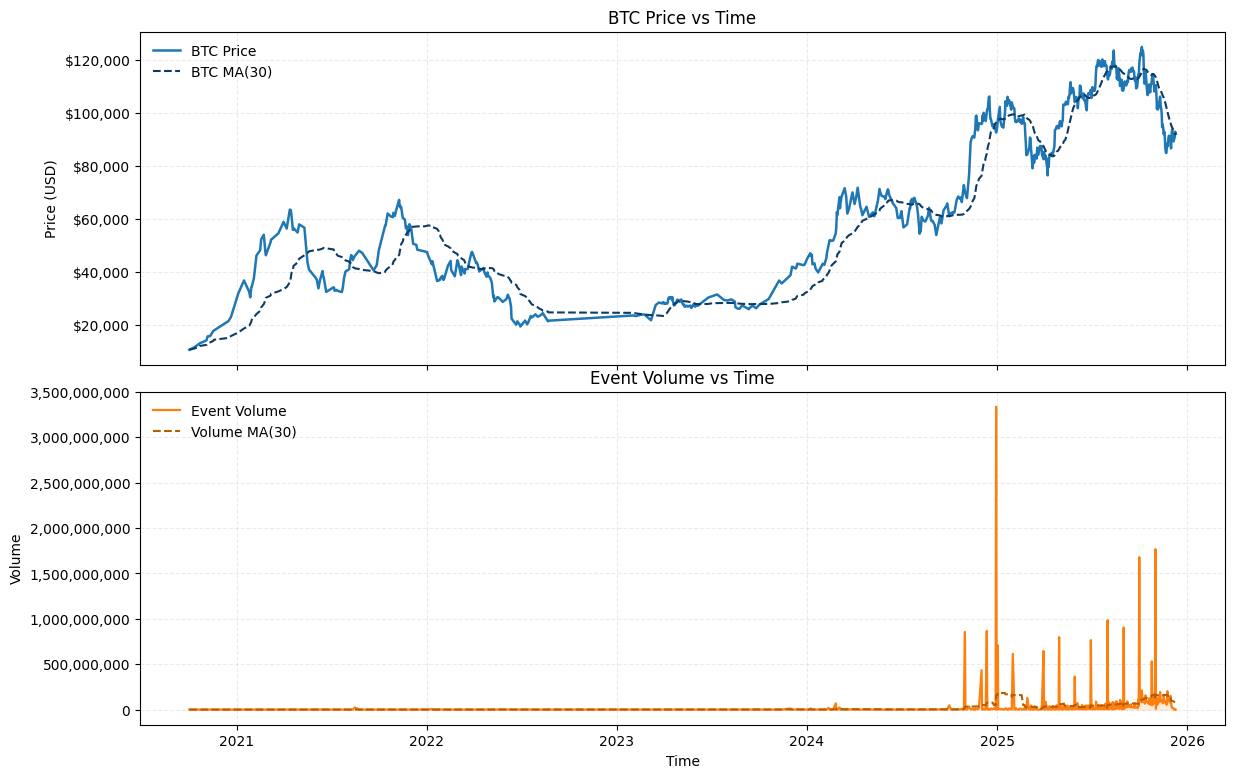

In [149]:
event_volume = crypto_event_stats.copy()
event_volume['time'] = pd.to_datetime(event_volume['first_market_start'], errors='coerce')
event_volume['date'] = event_volume['time'].dt.normalize()
event_volume = event_volume.groupby('date', as_index=False)['total_volume'].sum()

btc_daily = btc_pd[['time','btc_price']].copy()
btc_daily['date'] = pd.to_datetime(btc_daily['time'], errors='coerce').dt.normalize()
btc_daily = btc_daily.groupby('date', as_index=False)['btc_price'].mean()

merged = pd.merge(event_volume, btc_daily, on='date', how='inner')

merged = merged.sort_values('date').copy()

# Add moving average lines
merged['btc_price_ma30'] = merged['btc_price'].rolling(30, min_periods=1).mean()
merged['event_volume_ma30'] = merged['total_volume'].rolling(30, min_periods=1).mean()

fig, axes = plt.subplots(
    2, 1, figsize=(14, 9), sharex=True, gridspec_kw={'hspace': 0.08}
)

# BTC Price Plot
axes[0].plot(merged['date'], merged['btc_price'], color='#1f77b4', linewidth=1.8, label='BTC Price')
axes[0].plot(merged['date'], merged['btc_price_ma30'], color='#0d3b66', linestyle='--', linewidth=1.5, label='BTC MA(30)')
axes[0].set_title("BTC Price vs Time")
axes[0].set_ylabel("Price (USD)")
axes[0].grid(alpha=0.25, linestyle='--')
axes[0].legend(frameon=False, loc='upper left')
axes[0].yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

# Event Volume Plot
axes[1].plot(merged['date'], merged['total_volume'], color='#ff7f0e', linewidth=1.6, label='Event Volume')
axes[1].plot(merged['date'], merged['event_volume_ma30'], color='#b85c00', linestyle='--', linewidth=1.5, label='Volume MA(30)')
axes[1].fill_between(merged['date'], merged['total_volume'], color='#ff7f0e', alpha=0.12)
axes[1].set_title("Event Volume vs Time")
axes[1].set_ylabel("Volume")
axes[1].set_xlabel("Time")
axes[1].grid(alpha=0.25, linestyle='--')
axes[1].legend(frameon=False, loc='upper left')
axes[1].yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()


**Interpretation:**

1. Large volume spikes likely coincide with large BTC moves or major events.

2. Volume tends to increase during high BTC price volatility regimes.

**Finding:**

Polymarket trading activity increases during BTC price excitement. This suggests that Polymarket may be reactive to crypto macro movements.

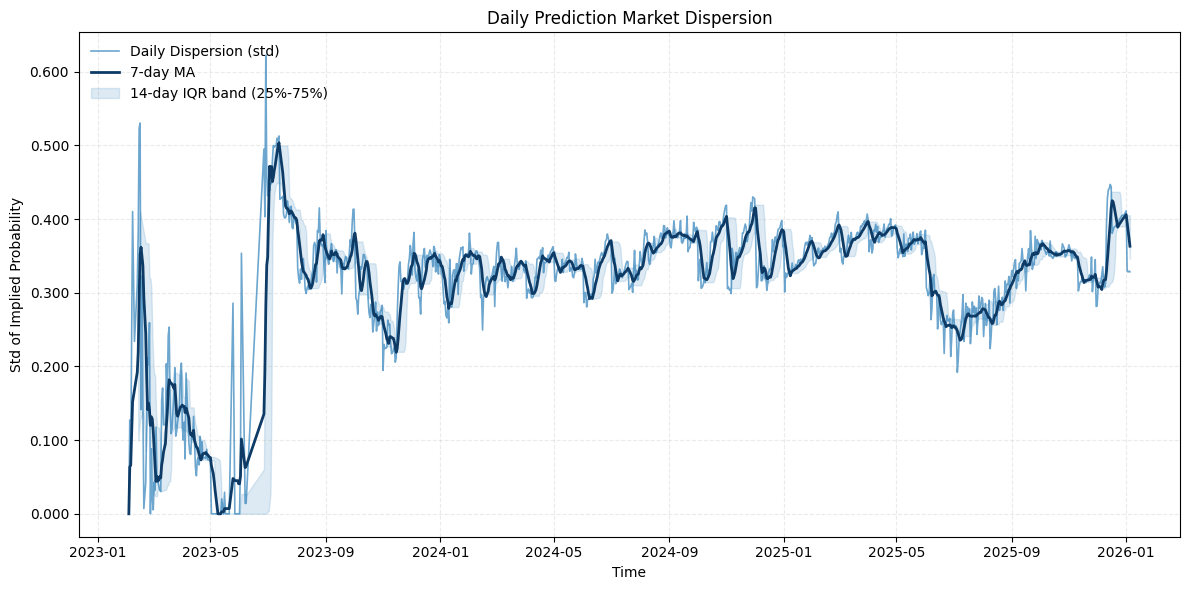

In [ ]:
# Daily implied probability dispersion
crypto_odds_history['date'] = crypto_odds_history['timestamp'].dt.date

daily_dispersion = crypto_odds_history.groupby('date')['price'].std().reset_index()
daily_dispersion['date'] = pd.to_datetime(daily_dispersion['date'])
daily_dispersion = daily_dispersion.sort_values('date')
daily_dispersion['disp_ma7'] = daily_dispersion['price'].rolling(7, min_periods=1).mean()
daily_dispersion['disp_q25'] = daily_dispersion['price'].rolling(14, min_periods=7).quantile(0.25)
daily_dispersion['disp_q75'] = daily_dispersion['price'].rolling(14, min_periods=7).quantile(0.75)


plt.figure(figsize=(12, 6))

# Dispersion
plt.plot(
    daily_dispersion['date'], daily_dispersion['price'],
    color='#1f77b4', linewidth=1.2, alpha=0.65, label='Daily Dispersion (std)'
)

# 7-day moving average
plt.plot(
    daily_dispersion['date'], daily_dispersion['disp_ma7'],
    color='#0d3b66', linewidth=2.0, label='7-day MA'
)

# IQR
plt.fill_between(
    daily_dispersion['date'],
    daily_dispersion['disp_q25'],
    daily_dispersion['disp_q75'],
    color='#1f77b4', alpha=0.15, label='14-day IQR band (25%-75%)'
)

plt.title("Daily Prediction Market Dispersion")
plt.xlabel("Time")
plt.ylabel("Std of Implied Probability")
plt.grid(alpha=0.25, linestyle='--')
plt.legend(frameon=False, loc='upper left')
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:.3f}'))
plt.tight_layout()
plt.show()


The market dispersion on day $t$ is given by:

$$\text{dispersion}_t = std(p_{i, t}),$$
where $p_{i, t}$ is the price of market $i$ on day $t$. It measures cross-sectional disagreement across prediction markets.

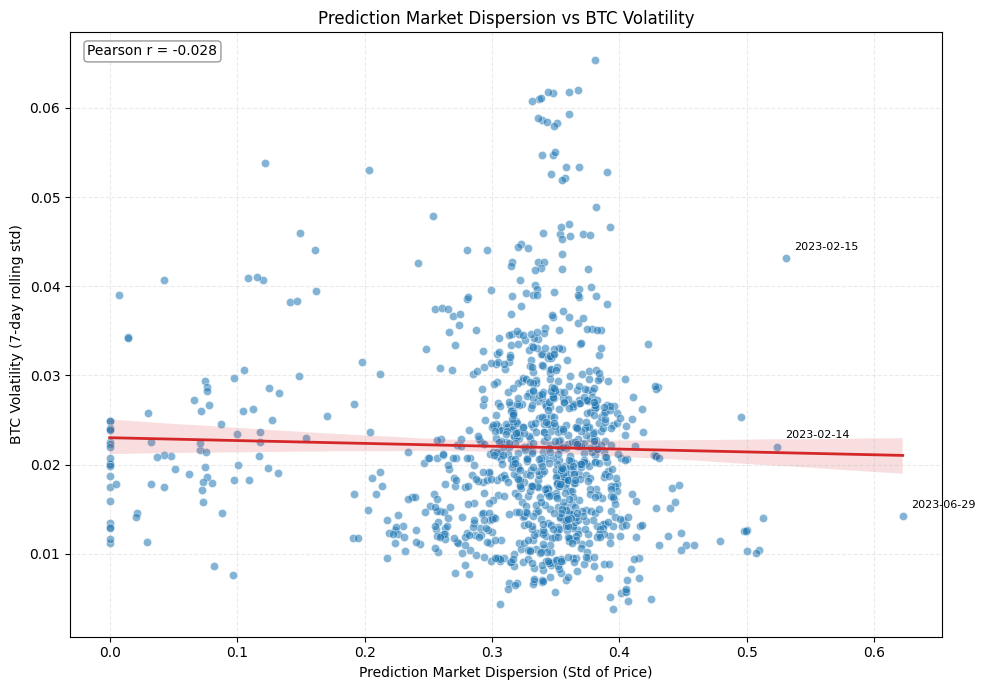

In [ ]:
# Merge volatility by date
vol_df = daily_dispersion[['date', 'price']].copy()
vol_df['date'] = pd.to_datetime(vol_df['date']).dt.normalize()

btc_vol = btc_pd[['time', 'btc_volatility_7d']].copy()
btc_vol['date'] = pd.to_datetime(btc_vol['time']).dt.normalize()
btc_vol = btc_vol.groupby('date', as_index=False)['btc_volatility_7d'].mean()

merged_vol = pd.merge(vol_df, btc_vol, on='date', how='inner').dropna()

# Correlation
corr = merged_vol['price'].corr(merged_vol['btc_volatility_7d'])

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=merged_vol,
    x='price',
    y='btc_volatility_7d',
    s=35,
    alpha=0.55,
    color='#1f77b4'
)

# Regression line + 95% CI
sns.regplot(
    data=merged_vol,
    x='price',
    y='btc_volatility_7d',
    scatter=False,
    ci=95,
    line_kws={'color': '#d62728', 'linewidth': 2}
)

# Pearson r correlation
plt.text(
    0.02, 0.98, f'Pearson r = {corr:.3f}',
    transform=plt.gca().transAxes,
    ha='left', va='top',
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.8, edgecolor='gray')
)

# Outliers
for i in merged_vol['price'].nlargest(3).index:
    plt.annotate(
        merged_vol.loc[i, 'date'].strftime('%Y-%m-%d'),
        (merged_vol.loc[i, 'price'], merged_vol.loc[i, 'btc_volatility_7d']),
        xytext=(6, 6),
        textcoords='offset points',
        fontsize=8
    )

plt.title("Prediction Market Dispersion vs BTC Volatility")
plt.xlabel("Prediction Market Dispersion (Std of Price)")
plt.ylabel("BTC Volatility (7-day rolling std)")
plt.grid(alpha=0.25, linestyle='--')
plt.tight_layout()
plt.show()


No obvious correlation found between market dispersion and BTC volatility.

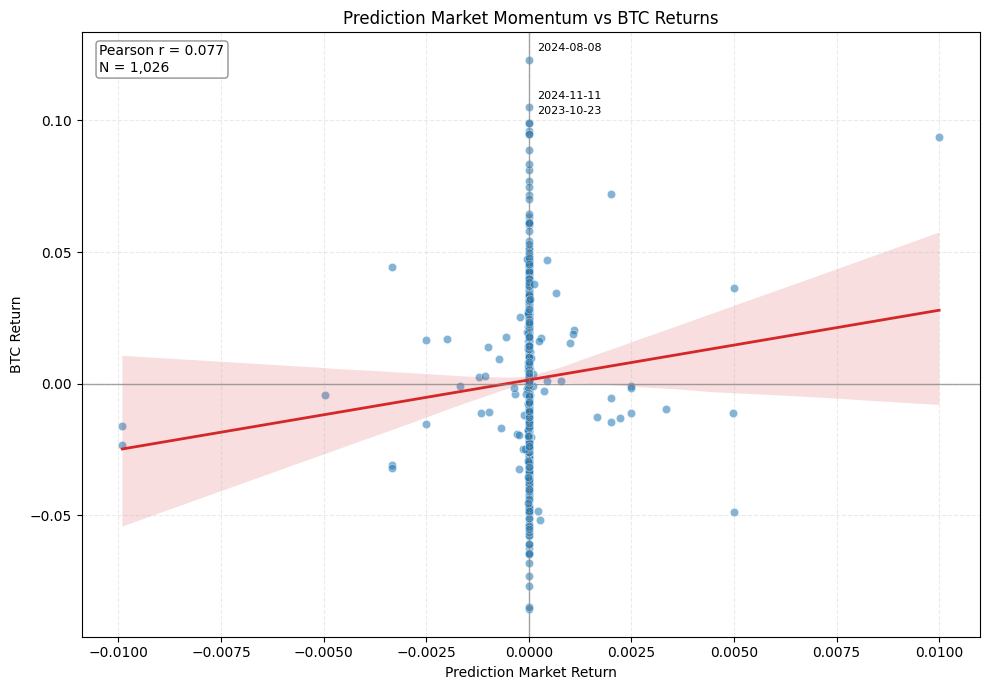

In [ ]:
# Compute daily mean price change rate (price return) in Polymarket data
daily_mean_price = crypto_odds_history.groupby('date')['price'].mean().reset_index()
daily_mean_price['price_return'] = daily_mean_price['price'].pct_change()

# Make join key datetime64 and align to day
daily_mean_price['date'] = pd.to_datetime(daily_mean_price['date'])
btc_daily = btc_pd[['time', 'btc_return']].copy()
btc_daily['time'] = pd.to_datetime(btc_daily['time']).dt.normalize()

# Merge
merged_momentum = pd.merge(
    daily_mean_price,
    btc_daily,
    left_on='date',
    right_on='time',
    how='inner'
)

plot_df = merged_momentum[['date', 'price_return', 'btc_return']].dropna().copy()
corr = plot_df['price_return'].corr(plot_df['btc_return'])
n = len(plot_df)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=plot_df,
    x='price_return',
    y='btc_return',
    s=36,
    alpha=0.55,
    color='#1f77b4'
)

# Regression line + 95% CI
sns.regplot(
    data=plot_df,
    x='price_return',
    y='btc_return',
    scatter=False,
    ci=95,
    line_kws={'color': '#d62728', 'linewidth': 2}
)

plt.axhline(0, color='gray', linewidth=1, alpha=0.7)
plt.axvline(0, color='gray', linewidth=1, alpha=0.7)

# Text in the graph
plt.text(
    0.02, 0.98, f'Pearson r = {corr:.3f}\nN = {n:,}',
    transform=plt.gca().transAxes,
    ha='left', va='top',
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85, edgecolor='gray')
)

# Show the 3 points with largest |btc_return|
for i in plot_df['btc_return'].abs().nlargest(3).index:
    plt.annotate(
        plot_df.loc[i, 'date'].strftime('%Y-%m-%d'),
        (plot_df.loc[i, 'price_return'], plot_df.loc[i, 'btc_return']),
        xytext=(6, 6),
        textcoords='offset points',
        fontsize=8
    )

plt.title("Prediction Market Momentum vs BTC Returns")
plt.xlabel("Prediction Market Return")
plt.ylabel("BTC Return")
plt.grid(alpha=0.25, linestyle='--')
plt.tight_layout()
plt.show()


The market momentum is very much similar with the BTC return, but instead it uses mean market price:

$$\text{momentum}_t = \frac{\bar{p}_t-\bar{p}_{t-1}}{\bar{p}_{t-1}},$$
where $\bar{p}_t = \frac{1}{N_t} \sum_{i=1}^{N_t} p_{i, t}$
and $N_t = \text{\# of active market at day } t$. It measures daily change rate of aggregate belief.

No obvious correlation found between market momentum and BTC return.

In [123]:
crypto_trades['date'] = crypto_trades['timestamp'].dt.date

# Trade volume
daily_trade_volume = crypto_trades.groupby('date')['size'].sum().reset_index()

# Buy vs Sell imbalance
imbalance = crypto_trades.groupby(['date','side'])['size'].sum().unstack(fill_value=0)
imbalance['order_imbalance'] = imbalance.get('BUY',0) - imbalance.get('SELL',0)
imbalance = imbalance.reset_index()

# Merge
trade_features = pd.merge(daily_trade_volume, imbalance[['date','order_imbalance']], on='date')

trade_features['date'] = pd.to_datetime(trade_features['date'])

merged_trade = pd.merge(
    trade_features,
    btc_pd[['time','btc_return']],
    left_on='date',
    right_on='time',
    how='inner'
)


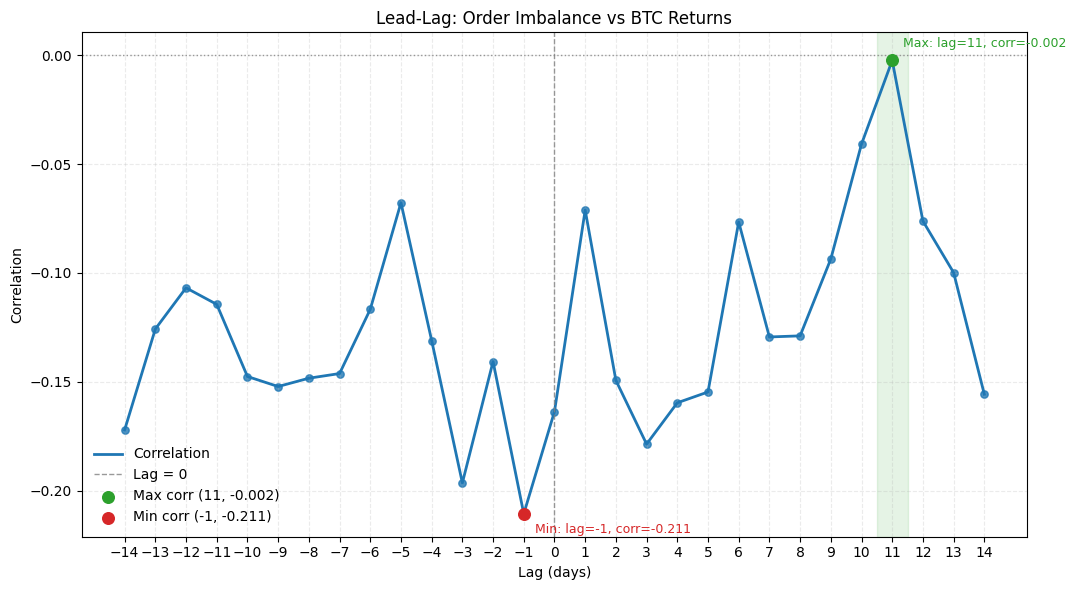

In [ ]:
# Draw Lead-Lag plot of order imbalance vs. BTC price
max_lag = 14
correlations = []

for lag in range(-max_lag, max_lag + 1):
    shifted = merged_trade['order_imbalance'].shift(lag)
    corr = shifted.corr(merged_trade['btc_return'])
    correlations.append(corr)

lag_vals = list(range(-max_lag, max_lag + 1))
corr_s = pd.Series(correlations, index=lag_vals)

best_lag = corr_s.idxmax()
best_corr = corr_s.loc[best_lag]
worst_lag = corr_s.idxmin()
worst_corr = corr_s.loc[worst_lag]

plt.figure(figsize=(11, 6))

plt.plot(lag_vals, correlations, color='#1f77b4', linewidth=2, label='Correlation')
plt.scatter(lag_vals, correlations, color='#1f77b4', s=28, alpha=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.8, label='Lag = 0')
plt.axhline(0, color='gray', linestyle=':', linewidth=1, alpha=0.8)

# Highlight the global maximum/minimum
plt.scatter(best_lag, best_corr, color='#2ca02c', s=70, zorder=5, label=f'Max corr ({best_lag}, {best_corr:.3f})')
plt.scatter(worst_lag, worst_corr, color='#d62728', s=70, zorder=5, label=f'Min corr ({worst_lag}, {worst_corr:.3f})')

# Shade at the global maximum
plt.axvspan(best_lag - 0.5, best_lag + 0.5, color='#2ca02c', alpha=0.12)

# Text in the graph
plt.annotate(
    f'Max: lag={best_lag}, corr={best_corr:.3f}',
    xy=(best_lag, best_corr), xytext=(8, 10),
    textcoords='offset points', fontsize=9, color='#2ca02c'
)
plt.annotate(
    f'Min: lag={worst_lag}, corr={worst_corr:.3f}',
    xy=(worst_lag, worst_corr), xytext=(8, -14),
    textcoords='offset points', fontsize=9, color='#d62728'
)

plt.title("Lead-Lag: Order Imbalance vs BTC Returns")
plt.xlabel("Lag (days)")
plt.ylabel("Correlation")
plt.xticks(lag_vals)
plt.grid(alpha=0.25, linestyle='--')
plt.legend(frameon=False, loc='best')
plt.tight_layout()
plt.show()


The formula of order imbalance is given by:

$$\text{order\_imbalance}_t = \text{total\_buy\_volumn}_t - \text{total\_sell\_volumn}_t.$$
It represents the net directional pressure in prediction market.

**Interpretation:**

Negative lag → imbalance leads BTC;

Positive lag → BTC leads imbalance;

**If peak correlation occurs at:**

Lag < 0 → Polymarket predicts BTC.

Lag = 0 → simultaneous reaction.

Lag > 0 → BTC moves first, Polymarket reacts.

**Findings:**

The local maximums basically appear symmetrically; the highest peak at the very right of the plot, suggesting that the order imbalance may occur as a reaction of BTC price change.

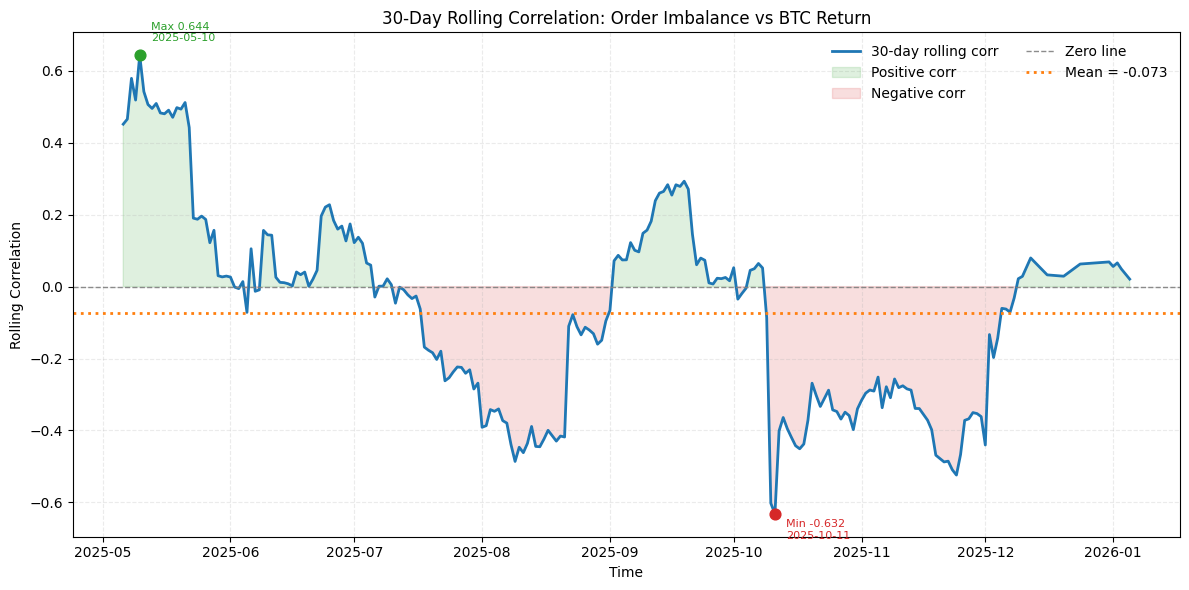

In [ ]:
# Compute 30-day rolling correlation between order imbalance and BTC return
merged_trade['rolling_corr'] = (
    merged_trade['order_imbalance']
    .rolling(30)
    .corr(merged_trade['btc_return'])
)

roll_corr = (
    merged_trade['order_imbalance']
    .rolling(30)
    .corr(merged_trade['btc_return'])
)

# Compute the statistics for the plot
plot_df = merged_trade[['date']].copy()
plot_df['rolling_corr'] = roll_corr
plot_df = plot_df.dropna().sort_values('date')

mean_corr = plot_df['rolling_corr'].mean()
max_idx = plot_df['rolling_corr'].idxmax()
min_idx = plot_df['rolling_corr'].idxmin()

max_date = plot_df.loc[max_idx, 'date']
max_val = plot_df.loc[max_idx, 'rolling_corr']
min_date = plot_df.loc[min_idx, 'date']
min_val = plot_df.loc[min_idx, 'rolling_corr']

# Draw the line plot for rolling correlation
plt.figure(figsize=(12, 6))

plt.plot(
    plot_df['date'], plot_df['rolling_corr'],
    color='#1f77b4', linewidth=2, label='30-day rolling corr'
)

# Fill the positive/negative areas
plt.fill_between(
    plot_df['date'], 0, plot_df['rolling_corr'],
    where=(plot_df['rolling_corr'] >= 0),
    color='#2ca02c', alpha=0.15, interpolate=True, label='Positive corr'
)
plt.fill_between(
    plot_df['date'], 0, plot_df['rolling_corr'],
    where=(plot_df['rolling_corr'] < 0),
    color='#d62728', alpha=0.15, interpolate=True, label='Negative corr'
)

plt.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.9, label='Zero line')
plt.axhline(mean_corr, color='#ff7f0e', linestyle=':', linewidth=2, label=f'Mean = {mean_corr:.3f}')

# Highlight the global maximum/minimum
plt.scatter([max_date], [max_val], color='#2ca02c', s=60, zorder=5)
plt.scatter([min_date], [min_val], color='#d62728', s=60, zorder=5)

# Text in the graph
plt.annotate(
    f'Max {max_val:.3f}\n{max_date:%Y-%m-%d}',
    (max_date, max_val), xytext=(8, 10),
    textcoords='offset points', fontsize=8, color='#2ca02c'
)
plt.annotate(
    f'Min {min_val:.3f}\n{min_date:%Y-%m-%d}',
    (min_date, min_val), xytext=(8, -18),
    textcoords='offset points', fontsize=8, color='#d62728'
)

plt.title("30-Day Rolling Correlation: Order Imbalance vs BTC Return")
plt.xlabel("Time")
plt.ylabel("Rolling Correlation")
plt.grid(alpha=0.25, linestyle='--')
plt.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()



**Interpretation:**

1. Correlation is time-varying and changes periodically.

2. Possibly weak during calm markets.

This indicates that order imbalance may not be a good indicator of BTC price.

**Summary:**

1. Crypto markets on Polymarket are dominated by a few large questions;

2. Lead-lag analysis probably shows that BTC return leads imbalance, suggesting that Polymarket is more reactive than predictive.

3. Rolling correlations show time-varying strength, so an important implication is that any predictive model must consider regime switching.

